===== Manual Metrics =====
MAE: 0.7010426719637758
MSE: 0.8065845639670531
RMSE: 0.8981005311027564
R2: 0.7692735413614223
Adjusted R2: 0.7669191897426614

===== Sklearn Metrics =====
MAE: 0.7010426719637758
MSE: 0.8065845639670531
RMSE: 0.8981005311027564
R2: 0.7692735413614223

===== Gradient Descent Result =====
Final m: 2.7978914556592676
Final b: 4.183635478882224


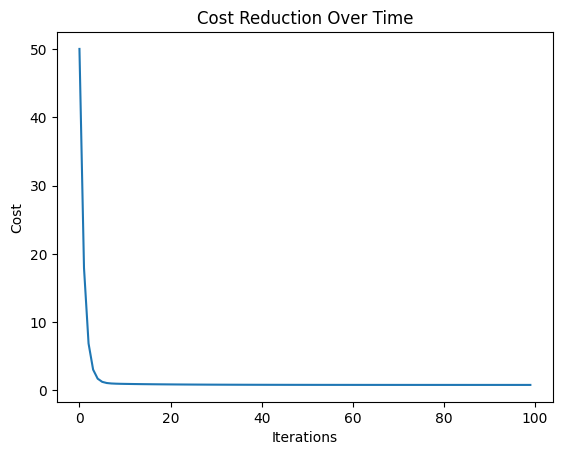

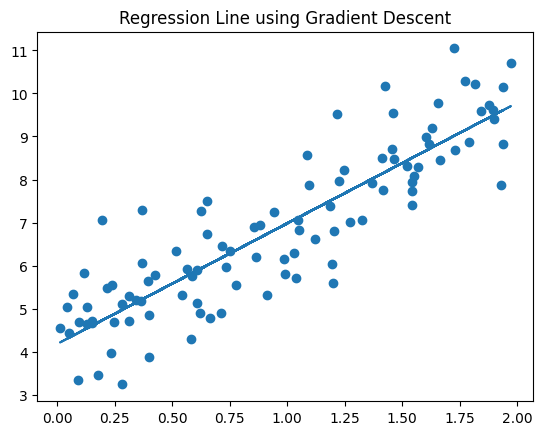

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# ==============================
# 1. DATASET GENERATION
# ==============================
np.random.seed(42)

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# ==============================
# 2. SKLEARN LINEAR REGRESSION
# ==============================
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# ==============================
# 3. MANUAL METRICS
# ==============================
n = len(y)

# MAE
mae_manual = np.mean(np.abs(y - y_pred))

# MSE
mse_manual = np.mean((y - y_pred)**2)

# RMSE
rmse_manual = np.sqrt(mse_manual)

# R2
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2_manual = 1 - (ss_res / ss_tot)

# Adjusted R2
p = X.shape[1]
adj_r2_manual = 1 - (1 - r2_manual) * (n - 1) / (n - p - 1)

print("===== Manual Metrics =====")
print("MAE:", mae_manual)
print("MSE:", mse_manual)
print("RMSE:", rmse_manual)
print("R2:", r2_manual)
print("Adjusted R2:", adj_r2_manual)

# ==============================
# 4. SKLEARN METRICS (VERIFY)
# ==============================
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("\n===== Sklearn Metrics =====")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

# ==============================
# 5. GRADIENT DESCENT
# ==============================
m = 0
b = 0
learning_rate = 0.1
iterations = 100

cost_history = []

for i in range(iterations):

    y_pred_gd = m * X + b

    # gradients
    dm = (-2/n) * np.sum(X * (y - y_pred_gd))
    db = (-2/n) * np.sum(y - y_pred_gd)

    # update
    m = m - learning_rate * dm
    b = b - learning_rate * db

    # cost
    cost = (1/n) * np.sum((y - y_pred_gd)**2)
    cost_history.append(cost)

print("\n===== Gradient Descent Result =====")
print("Final m:", m)
print("Final b:", b)

# ==============================
# 6. COST CURVE
# ==============================
plt.figure()
plt.plot(range(iterations), cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction Over Time")
plt.show()

# ==============================
# 7. REGRESSION LINE
# ==============================
plt.figure()
plt.scatter(X, y)
plt.plot(X, m * X + b)
plt.title("Regression Line using Gradient Descent")
plt.show()